## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results DiffGoL Model**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 1$  
$\lambda_{bin} = 1$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (20,20)
model_name = 'DiffGoL'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

cols2omit = 1
num_rows = 1
threshold = 0.5

figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'DiffGoL Model'
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

metrics2compute = ['Accuracy', 'Recall', 'Specificity','Precision', 'F1Score']

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name)

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.5962 ± 0.0021
val_loss: 0.6036 ± 0.0035


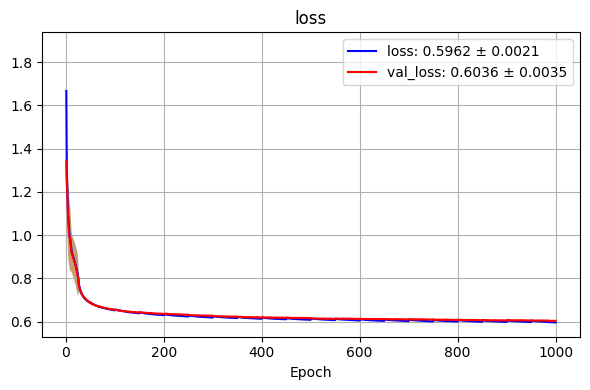

In [4]:
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8612 ± 0.0005
Accuracy_fin: 0.9144 ± 0.0009
Recall_init: 0.6447 ± 0.0020
Recall_fin: 0.6142 ± 0.0050
Specificity_init: 0.9201 ± 0.0007
Specificity_fin: 0.9929 ± 0.0002
Precision_init: 0.6871 ± 0.0014
Precision_fin: 0.9576 ± 0.0010
F1Score_init: 0.6652 ± 0.0012
F1Score_fin: 0.7484 ± 0.0036


--- Results Initial States (15 seeds) ---
Density (true): 21.40% ± 8.99%
Density (pred): 22.78% ± 9.28%
Error/seed:     1.39% ± 0.07%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 2.21% ± 0.04%
HUC% (0.4, 0.6): 4.53% ± 0.08%
HUC% (0.35, 0.65): 7.08% ± 0.10%
Fuzziness Index: 0.2653 ± 0.1373
MSE (prob):0.1045 ± 0.0594
MSE (bin):0.1388 ± 0.0811
MSE (all-zero): 0.2140 ± 0.0899
Wasserstein (EMD): 1.4229 ± 0.0025


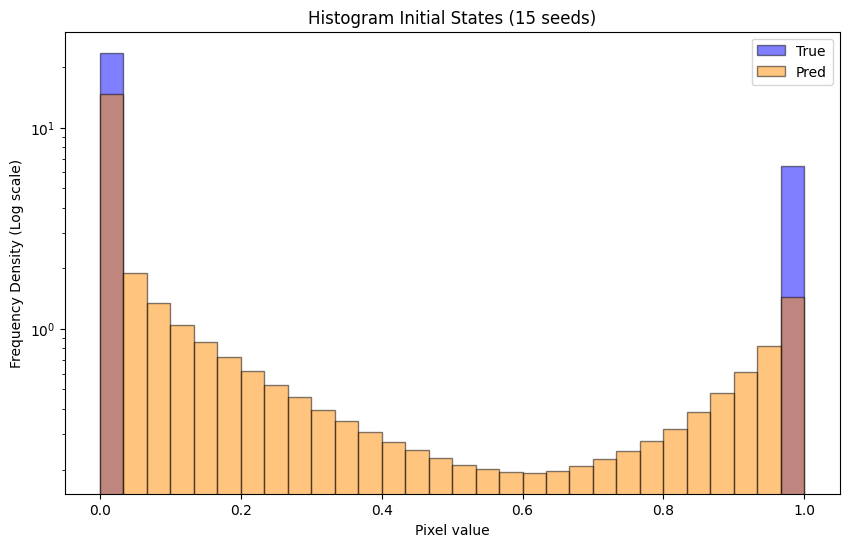

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 20.74% ± 9.05%
Density (pred): 12.82% ± 4.75%
Error/seed:     7.92% ± 0.06%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 2.37% ± 0.03%
HUC% (0.4, 0.6): 4.77% ± 0.05%
HUC% (0.35, 0.65): 7.19% ± 0.07%
Fuzziness Index: 0.1669 ± 0.0850
MSE (prob):0.0562 ± 0.0348
MSE (bin):0.0856 ± 0.0552
MSE (all-zero): 0.2074 ± 0.0905
Wasserstein (EMD): 1.5695 ± 0.0067


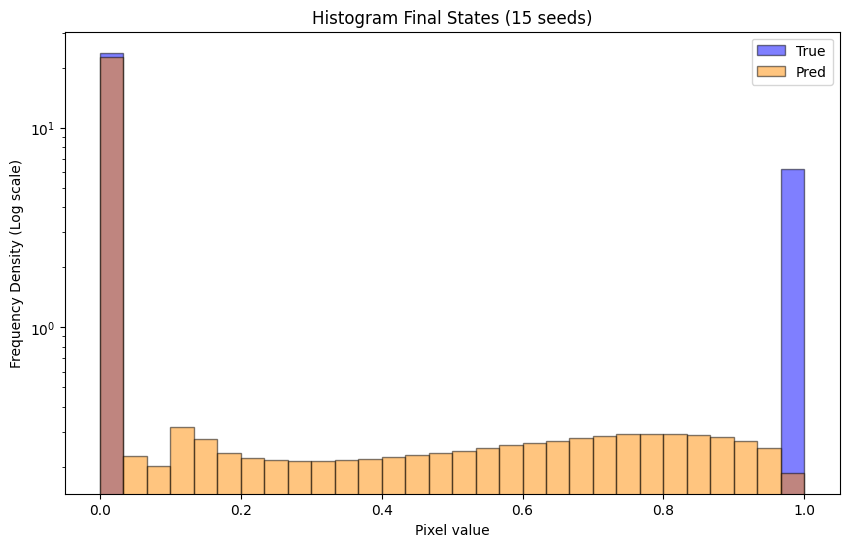

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

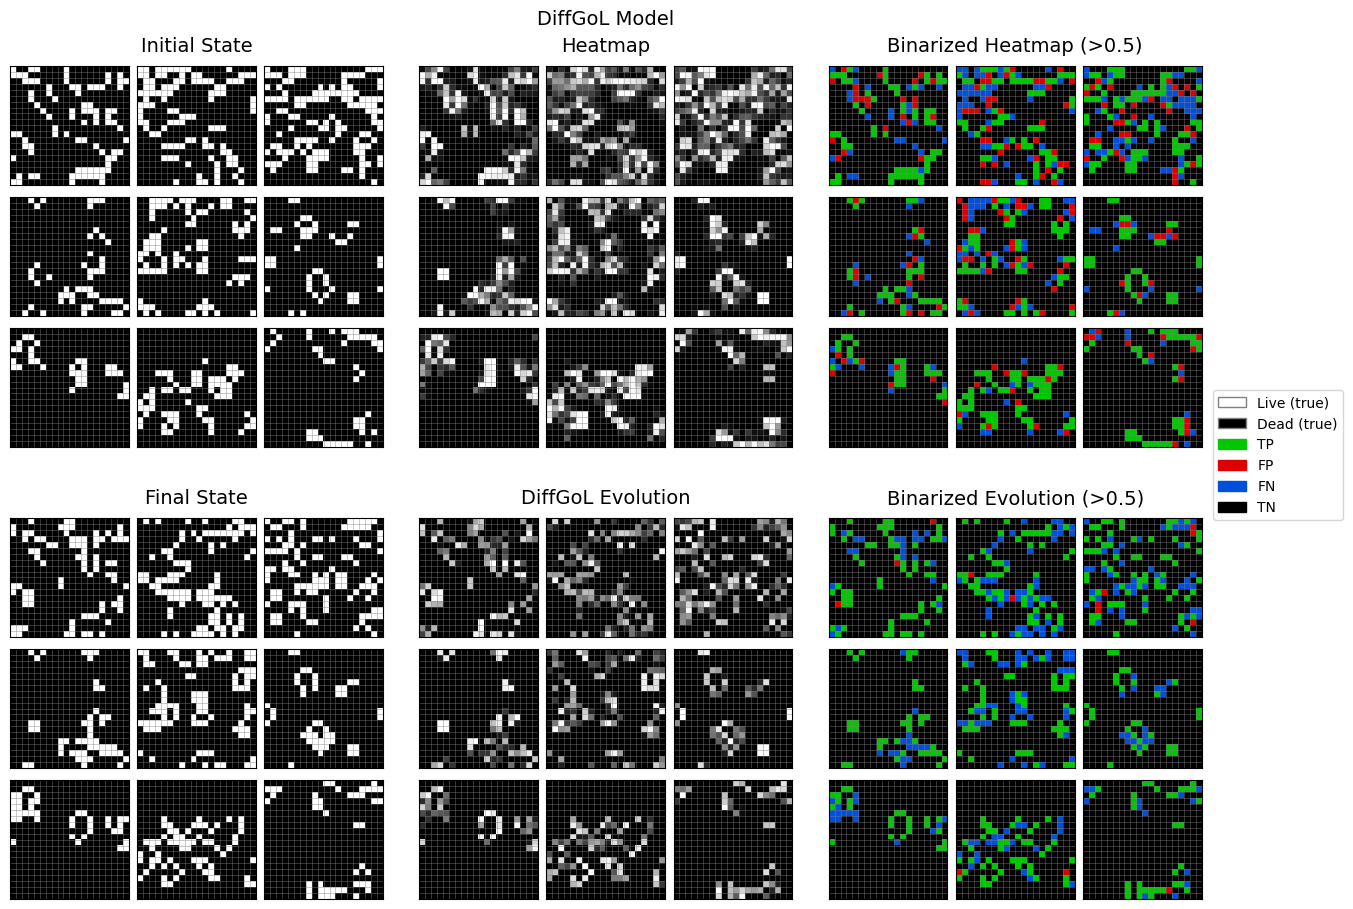

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False) 

### <span style='color:rgb(10,110,217)'><u>**Thresholds**</u></span>

Threshold: 0.2291 ± 0.0017


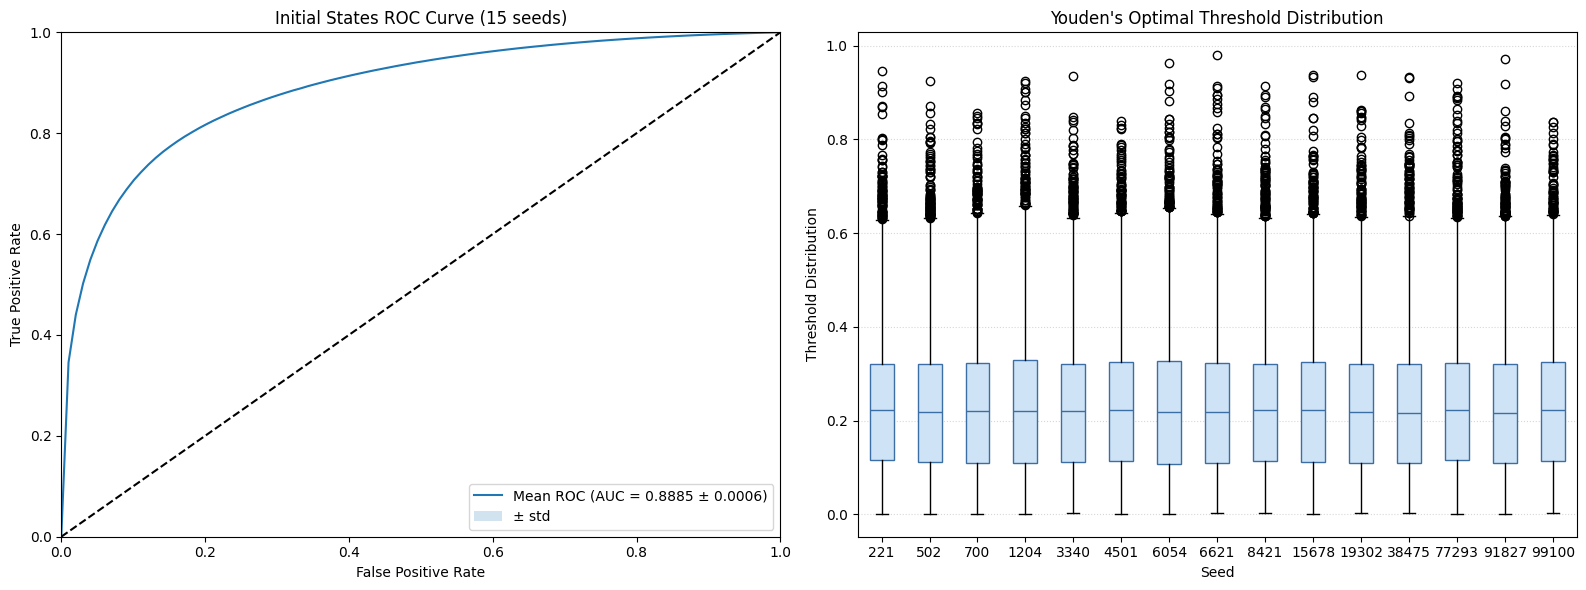

Threshold: 0.0922 ± 0.0022


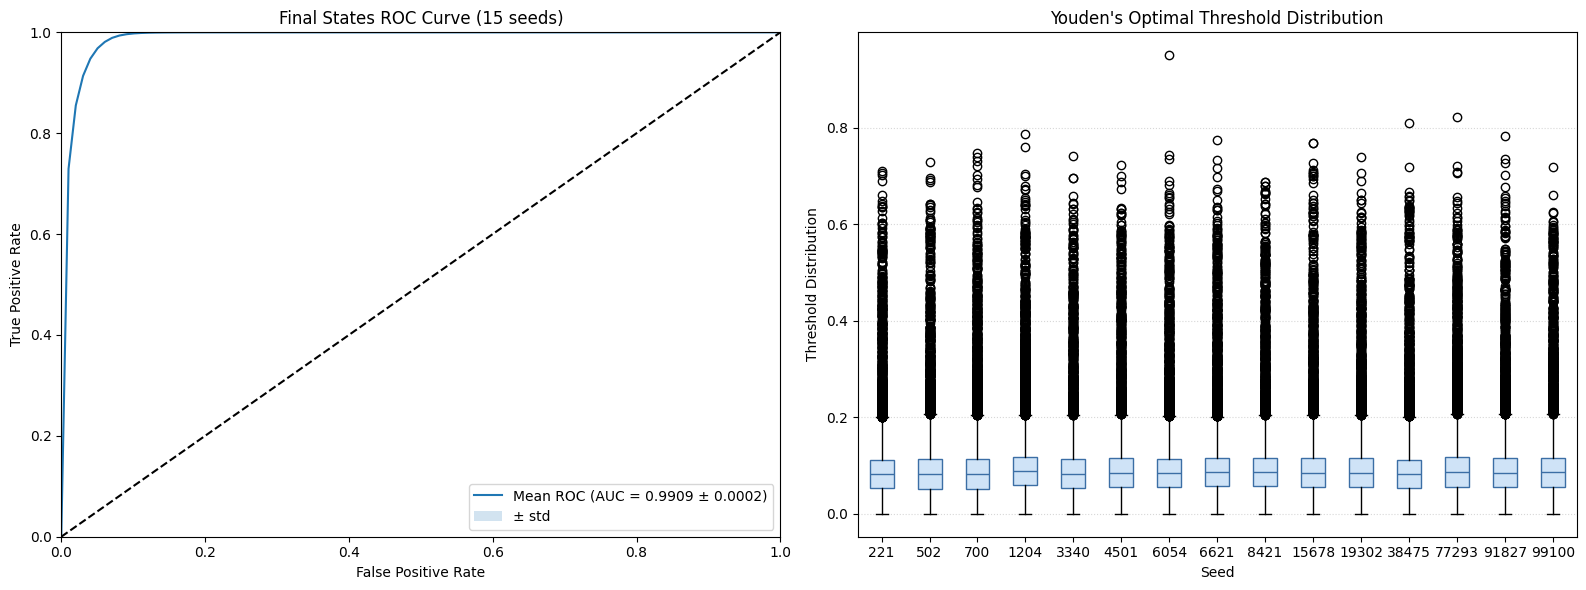

In [4]:
eval_tools.computeROC(predictions_paths, test_data, 'init', shape)
eval_tools.computeROC(predictions_paths, test_data, 'fin', shape)